# California Housing Price Prediction

## Machine Learning and Pattern Recognition Project

This project compares Linear Regression and Random Forest Regression models using the California Housing dataset from Scikit-Learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 1. Dataset Loading

The California Housing dataset is loaded from the sklearn.datasets library.

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Dataset loaded successfully!")

Dataset loaded successfully!


# 2. Data Exploration

The dataset is explored to understand its structure, dimensions, and statistical properties.

In [3]:
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Shape:", df.shape)

Shape: (20640, 9)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


# 3. Missing Value Analysis

The dataset is checked for missing values.

In [6]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# 4. Train-Test Split

The dataset is divided into training and testing sets using an 80/20 split.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (16512, 8)
Testing Set Shape: (4128, 8)


# 5. Feature Scaling

StandardScaler is applied to normalize feature values before training Linear Regression.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


# 6. Linear Regression

A Linear Regression model is trained and evaluated.

In [10]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [11]:
y_pred_lr = lr.predict(
    X_test_scaled
)

print(y_pred_lr[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [12]:
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

mse_lr = mean_squared_error(
    y_test,
    y_pred_lr
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("R² :", r2_lr)

Linear Regression Results
-------------------------
MAE: 0.5332001304956565
MSE: 0.5558915986952443
R² : 0.5757877060324508


# 7. Cross Validation

5-fold cross-validation is performed to evaluate model generalization.

In [13]:
cv_lr = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_lr)

print("\nAverage CV R²:")
print(cv_lr.mean())

Cross Validation Scores:
[0.62011512 0.61298876 0.6134416  0.61069973 0.60017477]

Average CV R²:
0.6114839952560993


# 8. Random Forest Regression

A Random Forest model is trained and evaluated.

In [14]:
rf = RandomForestRegressor(
    random_state=42
)

print("Random Forest model created.")

Random Forest model created.


In [15]:
cv_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_rf)

print("\nAverage CV R²:")
print(cv_rf.mean())

Cross Validation Scores:
[0.80899315 0.79381357 0.80828862 0.80440441 0.8051215 ]

Average CV R²:
0.8041242497453812


# 9. Hyperparameter Tuning

GridSearchCV is used to find the best hyperparameters for Random Forest.

In [16]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

In [17]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [18]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 20, 'n_estimators': 200}

Best CV Score:
0.8050524232098117


In [19]:
best_rf = grid.best_estimator_

best_rf.fit(
    X_train,
    y_train
)

print("Best Random Forest trained.")

Best Random Forest trained.


In [20]:
y_pred_rf = best_rf.predict(
    X_test
)

print(y_pred_rf[:10])

[0.50236919 0.73878139 4.89110695 2.53569889 2.25397522 1.6559531
 2.37326761 1.6606514  2.6377798  4.9012839 ]


In [21]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("----------------------")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R² :", r2_rf)

Random Forest Results
----------------------
MAE: 0.3271140672274751
MSE: 0.2545922861286096
R² : 0.8057153985083529


# 10. Model Comparison

The performance of Linear Regression and Random Forest Regression is compared using MAE, MSE, and R².

In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "MSE": [
        mse_lr,
        mse_rf
    ],
    "R2": [
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,MSE,R2
0,Linear Regression,0.533200,0.555892,0.575788
1,Random Forest,0.327114,0.254592,0.805715


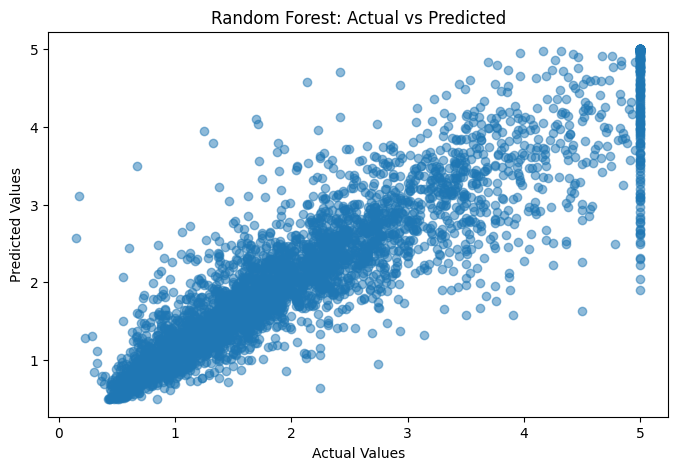

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()